# Phase 2: Market Segmentation via Clustering

In this notebook, you will:
1. Apply K-Means clustering to segment properties into market tiers
2. Use Hierarchical clustering and create dendrograms
3. Implement DBSCAN for density-based property grouping
4. Apply PCA for dimensionality reduction and visualization
5. Determine optimal clusters using Elbow method and Silhouette score
6. Interpret and visualize market segments

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features
from src.clustering import *

## 1. Data Preparation

In [2]:
df = load_housing_data()
X_scaled, y, feature_names, scaler = preprocess_features(df)
print(f"Features shape: {X_scaled.shape}")
print(f"Feature names: {feature_names}")

Features shape: (20640, 8)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 2. K-Means Clustering

### Finding Optimal K

Best k by silhouette score: 2


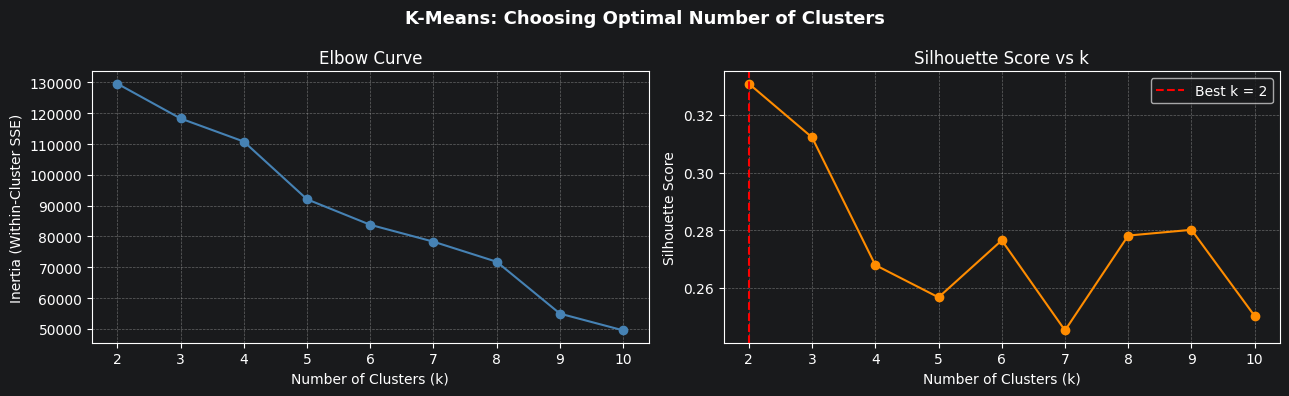

In [3]:

# --- Find Optimal K ---
k_results = find_optimal_k(X_scaled, k_range=range(2, 11))

best_k = k_results['best_k_silhouette']
print(f"Best k by silhouette score: {best_k}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow curve
axes[0].plot(k_results['k_range'], k_results['inertias'], marker='o', color='steelblue')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Silhouette scores
axes[1].plot(k_results['k_range'], k_results['silhouette_scores'], marker='o', color='darkorange')
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('K-Means: Choosing Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


K-Means Results (k=2)
  Inertia:         129,613.2
  Silhouette:      0.3308

Cluster sizes:
Cluster
0    11963
1     8677

Cluster profiles (mean feature values):
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
Cluster                                                                                               
0         3.918    28.413     5.225      1.076    1532.242     3.098    33.946    -118.01        2.138
1         3.805    28.952     5.710      1.126    1278.280     3.033    37.957    -121.72        1.972


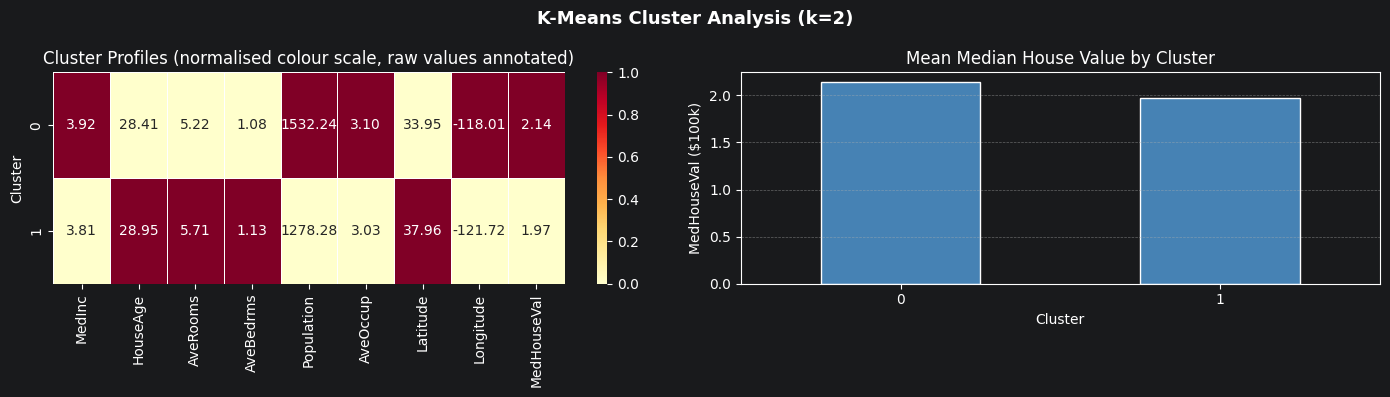

In [4]:

# --- K-Means with Optimal K ---
km_result = perform_kmeans(X_scaled, n_clusters=best_k)

print(f"K-Means Results (k={best_k})")
print(f"  Inertia:         {km_result['inertia']:,.1f}")
print(f"  Silhouette:      {km_result['silhouette']:.4f}")

# Attach cluster labels and target to a DataFrame for analysis
df_clusters = df.copy()
df_clusters['Cluster'] = km_result['labels']

# --- Cluster sizes ---
cluster_sizes = df_clusters['Cluster'].value_counts().sort_index()
print(f"\nCluster sizes:")
print(cluster_sizes.to_string())

# --- Cluster profiles: mean of each feature per cluster ---
profile_cols = feature_names + ['MedHouseVal']
cluster_profiles = df_clusters.groupby('Cluster')[profile_cols].mean().round(3)
print(f"\nCluster profiles (mean feature values):")
print(cluster_profiles.to_string())

# --- Visualise cluster profiles as a heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Normalise each feature column to [0, 1] so the heatmap is comparable
profile_norm = (cluster_profiles - cluster_profiles.min()) / (
    cluster_profiles.max() - cluster_profiles.min()
)
sns.heatmap(
    profile_norm,
    annot=cluster_profiles.values,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title('Cluster Profiles (normalised colour scale, raw values annotated)')
axes[0].set_ylabel('Cluster')

# Bar chart: median house value per cluster
cluster_profiles['MedHouseVal'].plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Mean Median House Value by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('MedHouseVal ($100k)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(f'K-Means Cluster Analysis (k={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Hierarchical Clustering

Dendrogram cut height for 2 clusters: 14.145


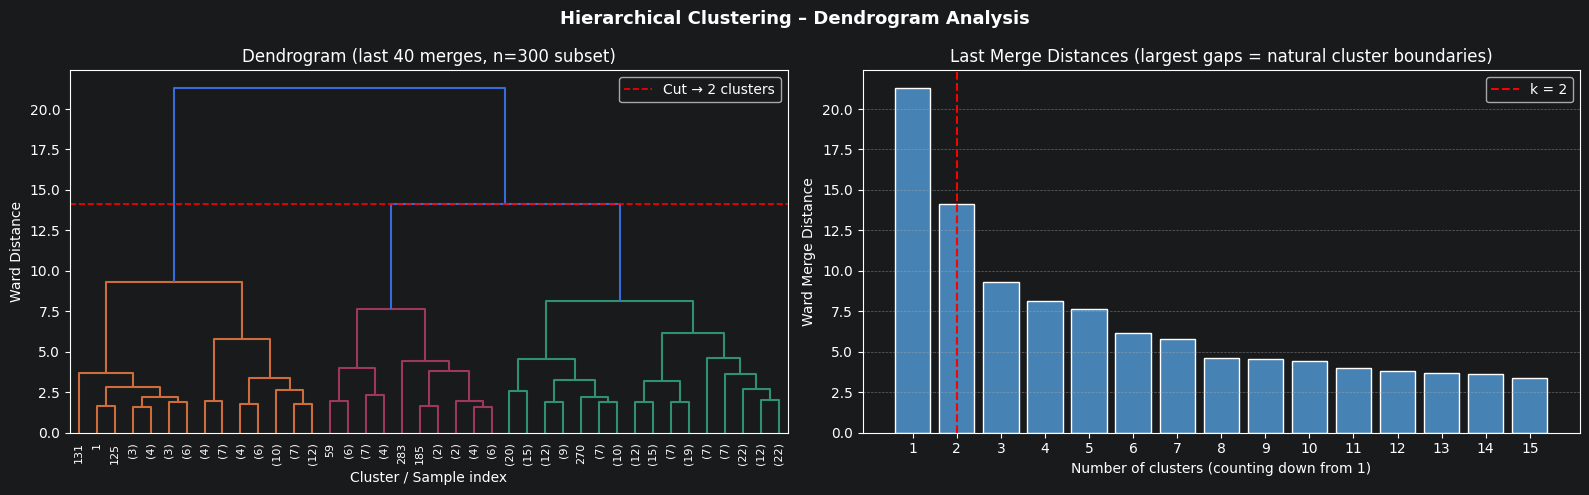

In [5]:

# --- Dendrogram on a subset for visualization ---
# Full dataset (20,640 rows) is too large for a readable dendrogram;
# a representative sample of 300 rows keeps it legible.
SUBSET_SIZE = 300
X_subset = X_scaled[:SUBSET_SIZE]

Z = compute_linkage_matrix(X_subset, method='ward')

# Height of the cut that produces best_k clusters:
# The linkage matrix rows are ordered by merge sequence.
# The (n - best_k)-th merge is the last one that still leaves best_k clusters.
cut_height = Z[-(best_k), 2]  # height just below the merge that reduces to best_k-1 clusters
print(f"Dendrogram cut height for {best_k} clusters: {cut_height:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: truncated dendrogram (last 40 merges) ---
dendrogram(
    Z,
    truncate_mode='lastp',
    p=40,
    color_threshold=cut_height,
    ax=axes[0],
    leaf_rotation=90,
    leaf_font_size=8,
)
axes[0].axhline(y=cut_height, color='red', linestyle='--', linewidth=1.2,
                label=f'Cut → {best_k} clusters')
axes[0].set_title(f'Dendrogram (last 40 merges, n={SUBSET_SIZE} subset)')
axes[0].set_xlabel('Cluster / Sample index')
axes[0].set_ylabel('Ward Distance')
axes[0].legend()

# --- Right: last-merges distance plot (scree-style) to show where the big jumps are ---
merge_distances = Z[:, 2]
last_n = 15
axes[1].bar(range(1, last_n + 1), merge_distances[-(last_n):][::-1],
            color='steelblue', edgecolor='white')
axes[1].axvline(x=best_k, color='red', linestyle='--',
                label=f'k = {best_k}')
axes[1].set_title('Last Merge Distances (largest gaps = natural cluster boundaries)')
axes[1].set_xlabel('Number of clusters (counting down from 1)')
axes[1].set_ylabel('Ward Merge Distance')
axes[1].set_xticks(range(1, last_n + 1))
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Hierarchical Clustering – Dendrogram Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Hierarchical Clustering Results (k=2, linkage=ward)
  Silhouette:  0.3213
  K-Means sil: 0.3308

Label agreement (cross-tabulation):
Hierarchical     0      1
K-Means                  
0               71  11892
1             7673   1004

Hierarchical cluster profiles (mean feature values):
            MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
HC_Cluster                                                                                               
0            3.761    29.378     5.781      1.149    1237.885     2.751    38.074   -121.854        2.014
1            3.937    28.196     5.218      1.065    1538.125     3.262    34.166   -118.198        2.102


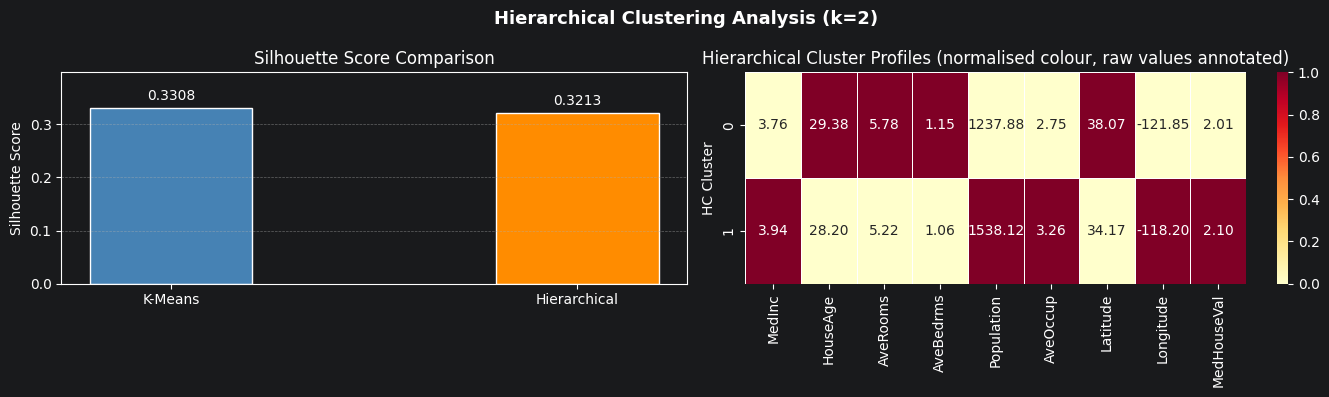

In [6]:

# --- Hierarchical clustering on the full dataset ---
hc_result = perform_hierarchical_clustering(X_scaled, n_clusters=best_k, linkage_method='ward')

print(f"Hierarchical Clustering Results (k={best_k}, linkage=ward)")
print(f"  Silhouette:  {hc_result['silhouette']:.4f}")
print(f"  K-Means sil: {km_result['silhouette']:.4f}")

# --- Label agreement: cross-tabulation of K-Means vs Hierarchical labels ---
agreement_df = pd.crosstab(
    km_result['labels'],
    hc_result['labels'],
    rownames=['K-Means'],
    colnames=['Hierarchical']
)
print(f"\nLabel agreement (cross-tabulation):")
print(agreement_df.to_string())

# --- Hierarchical cluster profiles ---
df_hc = df.copy()
df_hc['HC_Cluster'] = hc_result['labels']
hc_profiles = df_hc.groupby('HC_Cluster')[feature_names + ['MedHouseVal']].mean().round(3)
print(f"\nHierarchical cluster profiles (mean feature values):")
print(hc_profiles.to_string())

# --- Side-by-side silhouette comparison and profile heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Silhouette comparison bar chart
labels_bar = ['K-Means', 'Hierarchical']
scores_bar = [km_result['silhouette'], hc_result['silhouette']]
colors_bar = ['steelblue', 'darkorange']
bars = axes[0].bar(labels_bar, scores_bar, color=colors_bar, edgecolor='white', width=0.4)
axes[0].bar_label(bars, fmt='%.4f', padding=3)
axes[0].set_ylim(0, max(scores_bar) * 1.2)
axes[0].set_title('Silhouette Score Comparison')
axes[0].set_ylabel('Silhouette Score')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Hierarchical cluster profiles heatmap
hc_norm = (hc_profiles - hc_profiles.min()) / (hc_profiles.max() - hc_profiles.min())
sns.heatmap(
    hc_norm,
    annot=hc_profiles.values,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title('Hierarchical Cluster Profiles (normalised colour, raw values annotated)')
axes[1].set_ylabel('HC Cluster')

plt.suptitle(f'Hierarchical Clustering Analysis (k={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. DBSCAN Clustering

Full tuning grid results:
 eps  min_samples  n_clusters  n_noise  silhouette  noise_pct
 0.3            5         150    12850   -0.299798       62.3
 0.3           10          20    15800   -0.120315       76.6
 0.3           20           7    18063    0.033735       87.5
 0.3           50           2    19972    0.808786       96.8
 0.5            5          25     2982   -0.384145       14.4
 0.5           10           7     4281   -0.111190       20.7
 0.5           20           3     6400    0.155233       31.0
 0.5           50           8    11039    0.203515       53.5
 0.7            5          16      988    0.115365        4.8
 0.7           10           2     1363    0.562128        6.6
 0.7           20           1     1902         NaN        9.2
 0.7           50           1     3132         NaN       15.2
 1.0            5           3      308    0.556005        1.5
 1.0           10           1      415         NaN        2.0
 1.0           20           1      591      

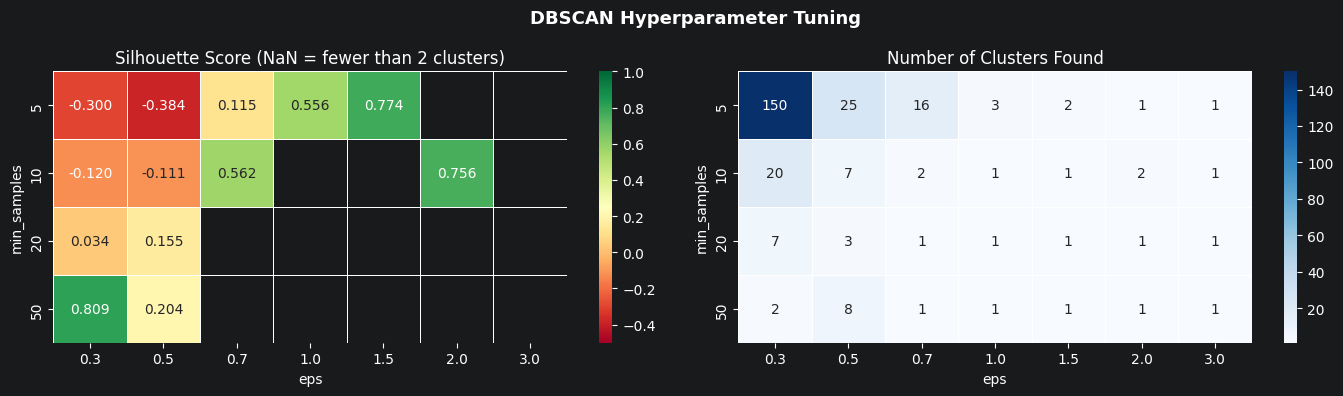

In [7]:

# --- Tune DBSCAN hyperparameters ---
eps_range       = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
min_samples_range = [5, 10, 20, 50]

tune_results = tune_dbscan(X_scaled, eps_range=eps_range, min_samples_range=min_samples_range)
tune_results['noise_pct'] = (tune_results['n_noise'] / len(X_scaled) * 100).round(1)

print("Full tuning grid results:")
print(tune_results.to_string(index=False))

# --- Select best parameters: ≥2 clusters, <10% noise, highest silhouette ---
valid = tune_results[
    (tune_results['n_clusters'] >= 2) &
    (tune_results['noise_pct'] < 10.0) &
    (tune_results['silhouette'].notna())
].copy()

best_row      = valid.loc[valid['silhouette'].idxmax()]
best_eps      = best_row['eps']
best_min_samp = int(best_row['min_samples'])

print(f"\nBest parameters → eps={best_eps}, min_samples={best_min_samp}")
print(f"  n_clusters: {int(best_row['n_clusters'])}  |  "
      f"noise: {int(best_row['n_noise'])} ({best_row['noise_pct']:.1f}%)  |  "
      f"silhouette: {best_row['silhouette']:.4f}")

# --- Heatmap: silhouette score across the grid ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sil_pivot = tune_results.pivot(index='min_samples', columns='eps', values='silhouette')
n_pivot   = tune_results.pivot(index='min_samples', columns='eps', values='n_clusters')

sns.heatmap(sil_pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[0], vmin=-0.5, vmax=1.0)
axes[0].set_title('Silhouette Score (NaN = fewer than 2 clusters)')
axes[0].set_xlabel('eps')
axes[0].set_ylabel('min_samples')

sns.heatmap(n_pivot, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Number of Clusters Found')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('min_samples')

plt.suptitle('DBSCAN Hyperparameter Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


DBSCAN Results (eps=1.5, min_samples=5)
  Clusters found:  2
  Noise points:    112 (0.5%)
  Silhouette:      0.7739

Points per label (−1 = noise):
  noise       :    112  (0.5%)
  cluster 0   :  20523  (99.4%)
  cluster 1   :      5  (0.0%)

Cluster profiles (noise excluded):
              MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
DBSCAN_Label                                                                                               
0              3.868    28.693     5.330      1.076    1417.955     2.932    35.625    -119.57        2.070
1              3.526    12.400    28.715      5.293     195.200     2.023    38.788    -120.36        1.366


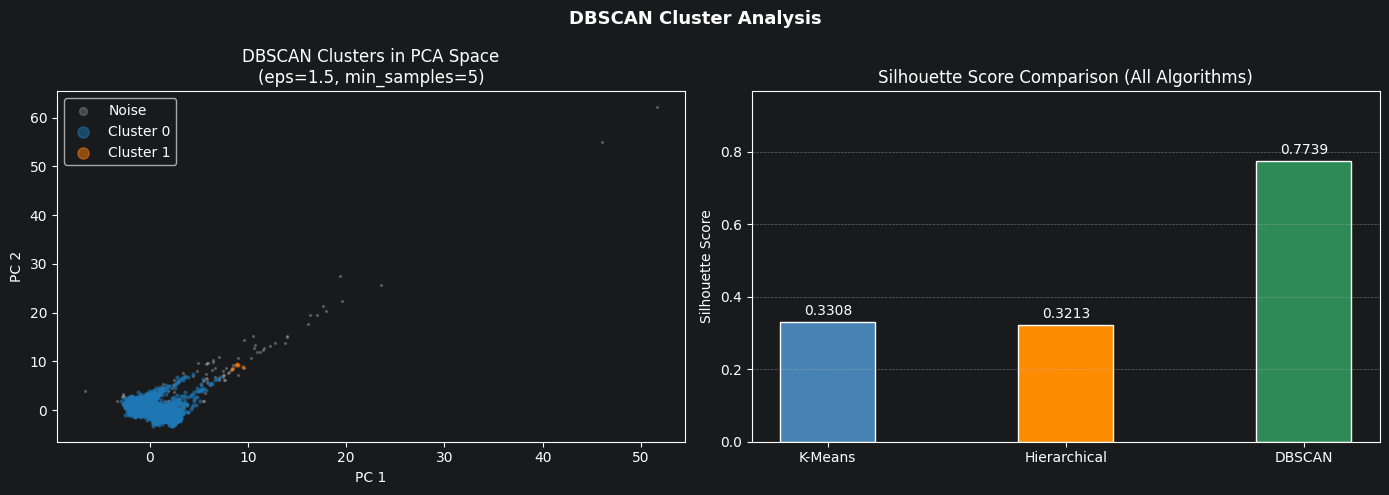

In [8]:

# --- Run DBSCAN with best parameters ---
db_result = perform_dbscan(X_scaled, eps=best_eps, min_samples=best_min_samp)

print(f"DBSCAN Results (eps={best_eps}, min_samples={best_min_samp})")
print(f"  Clusters found:  {db_result['n_clusters']}")
print(f"  Noise points:    {db_result['n_noise']} "
      f"({db_result['n_noise'] / len(X_scaled) * 100:.1f}%)")
print(f"  Silhouette:      {db_result['silhouette']:.4f}")

# --- Cluster composition ---
db_labels = db_result['labels']
unique_labels = sorted(set(db_labels))
print(f"\nPoints per label (−1 = noise):")
for lbl in unique_labels:
    count = int((db_labels == lbl).sum())
    tag = 'noise' if lbl == -1 else f'cluster {lbl}'
    print(f"  {tag:12s}: {count:6d}  ({count / len(X_scaled) * 100:.1f}%)")

# --- Cluster profiles (non-noise points only) ---
df_db = df.copy()
df_db['DBSCAN_Label'] = db_labels
non_noise = df_db[df_db['DBSCAN_Label'] != -1]
db_profiles = non_noise.groupby('DBSCAN_Label')[feature_names + ['MedHouseVal']].mean().round(3)
print(f"\nCluster profiles (noise excluded):")
print(db_profiles.to_string())

# --- Silhouette comparison across all three algorithms ---
sil_scores = {
    'K-Means':      km_result['silhouette'],
    'Hierarchical': hc_result['silhouette'],
    'DBSCAN':       db_result['silhouette'],
}

# --- Visualise: 2-D PCA scatter + silhouette bar ---
from src.clustering import perform_pca

pca2 = perform_pca(X_scaled, n_components=2)
pca_data = pca2['transformed']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: clusters in colour, noise in grey
palette = {-1: '#cccccc'}  # noise = grey
cluster_ids = sorted(lbl for lbl in unique_labels if lbl != -1)
colors_c = plt.cm.tab10.colors
for i, lbl in enumerate(cluster_ids):
    palette[lbl] = colors_c[i % len(colors_c)]

for lbl in unique_labels:
    mask = db_labels == lbl
    label_str = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    alpha = 0.25 if lbl == -1 else 0.5
    size  = 2    if lbl == -1 else 4
    axes[0].scatter(
        pca_data[mask, 0], pca_data[mask, 1],
        c=palette[lbl], label=label_str,
        s=size, alpha=alpha, rasterized=True
    )
axes[0].set_title(f'DBSCAN Clusters in PCA Space\n(eps={best_eps}, min_samples={best_min_samp})')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
axes[0].legend(markerscale=4, loc='best')

# Silhouette comparison bar
bar_colors = ['steelblue', 'darkorange', 'seagreen']
bars = axes[1].bar(sil_scores.keys(), sil_scores.values(),
                   color=bar_colors, edgecolor='white', width=0.4)
axes[1].bar_label(bars, fmt='%.4f', padding=3)
axes[1].set_ylim(0, max(sil_scores.values()) * 1.25)
axes[1].set_title('Silhouette Score Comparison (All Algorithms)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('DBSCAN Cluster Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. PCA & Visualization

Total features: 8
Components needed for 95% variance: 6

Per-component explained variance:
  PC1: 0.2534  (cumulative: 0.2534)  ##########
  PC2: 0.2352  (cumulative: 0.4885)  #########
  PC3: 0.1589  (cumulative: 0.6474)  ######
  PC4: 0.1289  (cumulative: 0.7763)  #####
  PC5: 0.1254  (cumulative: 0.9017)  #####
  PC6: 0.0824  (cumulative: 0.9841)  ###
  PC7: 0.0102  (cumulative: 0.9943)  
  PC8: 0.0057  (cumulative: 1.0000)  


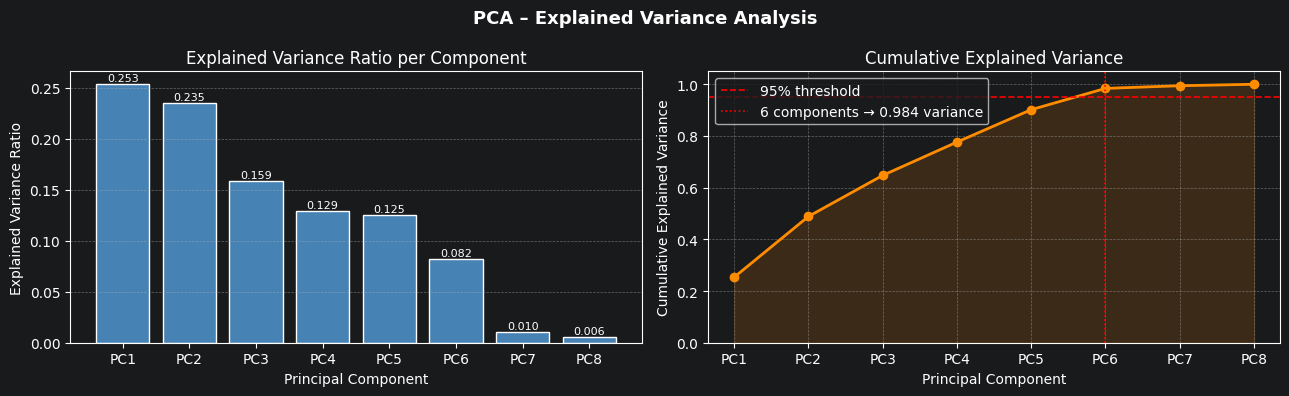

In [9]:

# --- Full PCA: explained variance profile ---
pca_full = perform_pca(X_scaled)           # all 8 components
n_opt    = find_optimal_components(X_scaled, variance_threshold=0.95)

print(f"Total features: {X_scaled.shape[1]}")
print(f"Components needed for 95% variance: {n_opt}")
print()
print("Per-component explained variance:")
for i, (evr, cum) in enumerate(
    zip(pca_full['explained_variance_ratio'], pca_full['cumulative_variance']), 1
):
    bar = '#' * int(evr * 40)
    print(f"  PC{i}: {evr:.4f}  (cumulative: {cum:.4f})  {bar}")

# --- Plot: bar chart of individual EVR + cumulative line ---
n_comp   = pca_full['n_components']
comp_ids = [f'PC{i+1}' for i in range(n_comp)]
evr      = pca_full['explained_variance_ratio']
cum_var  = pca_full['cumulative_variance']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Individual explained variance
axes[0].bar(comp_ids, evr, color='steelblue', edgecolor='white')
axes[0].set_title('Explained Variance Ratio per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(evr):
    axes[0].text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=8)

# Cumulative variance with threshold
axes[1].plot(comp_ids, cum_var, marker='o', color='darkorange', linewidth=2)
axes[1].axhline(y=0.95, color='red', linestyle='--', linewidth=1.2,
                label='95% threshold')
axes[1].axvline(x=n_opt - 1, color='red', linestyle=':', linewidth=1.2,
                label=f'{n_opt} components → {cum_var[n_opt-1]:.3f} variance')
axes[1].fill_between(range(n_comp), cum_var, alpha=0.15, color='darkorange')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('PCA – Explained Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


PCA + K-Means (k=2, 2 components)
  Silhouette (PCA space): 0.5891
  Silhouette (full space): 0.3308  ← K-Means on raw features


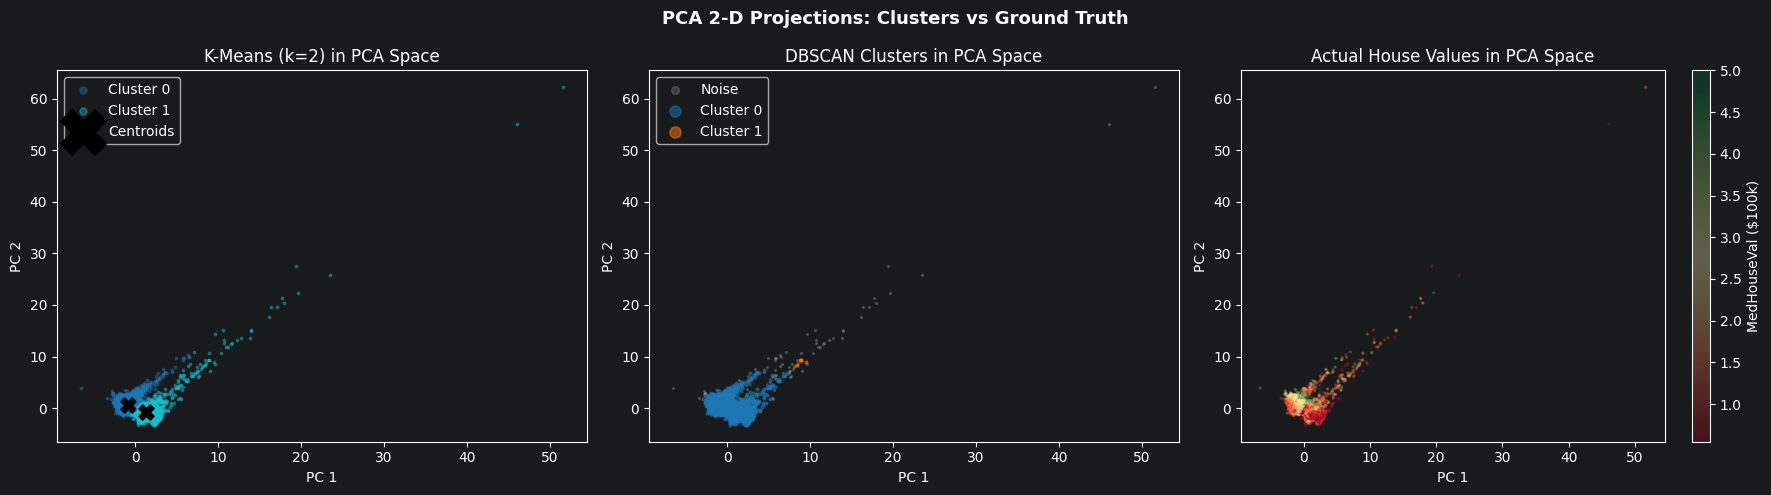

In [10]:

# --- cluster_with_pca: PCA reduction → K-Means in 2-D space ---
pca_km = cluster_with_pca(X_scaled, n_clusters=best_k, n_components=2)

print(f"PCA + K-Means (k={best_k}, 2 components)")
print(f"  Silhouette (PCA space): {pca_km['silhouette']:.4f}")
print(f"  Silhouette (full space): {km_result['silhouette']:.4f}  ← K-Means on raw features")

pc_xy   = pca_km['pca_data']        # shape (n, 2)
pc_labs = pca_km['labels']

# Build a palette for best_k clusters
cmap_km = plt.cm.get_cmap('tab10', best_k)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Left: PCA + K-Means cluster scatter ---
for lbl in range(best_k):
    mask = pc_labs == lbl
    axes[0].scatter(
        pc_xy[mask, 0], pc_xy[mask, 1],
        color=cmap_km(lbl), label=f'Cluster {lbl}',
        s=3, alpha=0.4, rasterized=True
    )
# Overlay centroids (transform K-Means centroids are in PCA space already)
centroids_pca = pca_km['kmeans_model'].cluster_centers_
axes[0].scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', marker='X', s=120, zorder=5, label='Centroids'
)
axes[0].set_title(f'K-Means (k={best_k}) in PCA Space')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
axes[0].legend(markerscale=3, loc='best')

# --- Middle: DBSCAN labels on the same PCA axes (reuse pca_data from cell-12) ---
palette_db = {-1: '#cccccc'}
colors_c = plt.cm.tab10.colors
for i, lbl in enumerate(sorted(lbl for lbl in unique_labels if lbl != -1)):
    palette_db[lbl] = colors_c[i % len(colors_c)]

for lbl in unique_labels:
    mask = db_labels == lbl
    label_str = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    alpha = 0.2 if lbl == -1 else 0.5
    sz    = 2   if lbl == -1 else 4
    axes[1].scatter(
        pca_data[mask, 0], pca_data[mask, 1],
        c=palette_db[lbl], label=label_str,
        s=sz, alpha=alpha, rasterized=True
    )
axes[1].set_title('DBSCAN Clusters in PCA Space')
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')
axes[1].legend(markerscale=4, loc='best')

# --- Right: house value gradient on PCA axes (ground truth overlay) ---
sc = axes[2].scatter(
    pc_xy[:, 0], pc_xy[:, 1],
    c=y, cmap='RdYlGn', s=2, alpha=0.3, rasterized=True,
    vmin=np.percentile(y, 2), vmax=np.percentile(y, 98)
)
plt.colorbar(sc, ax=axes[2], label='MedHouseVal ($100k)')
axes[2].set_title('Actual House Values in PCA Space')
axes[2].set_xlabel('PC 1')
axes[2].set_ylabel('PC 2')

plt.suptitle('PCA 2-D Projections: Clusters vs Ground Truth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Cluster Interpretation

TODO: For each cluster, analyze:
- Average feature values
- Price distribution
- Geographic distribution
- What "market tier" does each cluster represent?

Market Tier Summary:
                SoCal Market (Cluster 0)  NorCal Market (Cluster 1)
n_properties                   11963.000                   8677.000
mean_income                        3.918                      3.805
mean_age                          28.413                     28.952
mean_rooms                         5.225                      5.710
mean_pop                        1532.242                   1278.280
mean_occupancy                     3.098                      3.033
mean_lat                          33.946                     37.957
mean_lon                        -118.010                   -121.720
mean_price                         2.138                      1.972
median_price                       1.857                      1.656


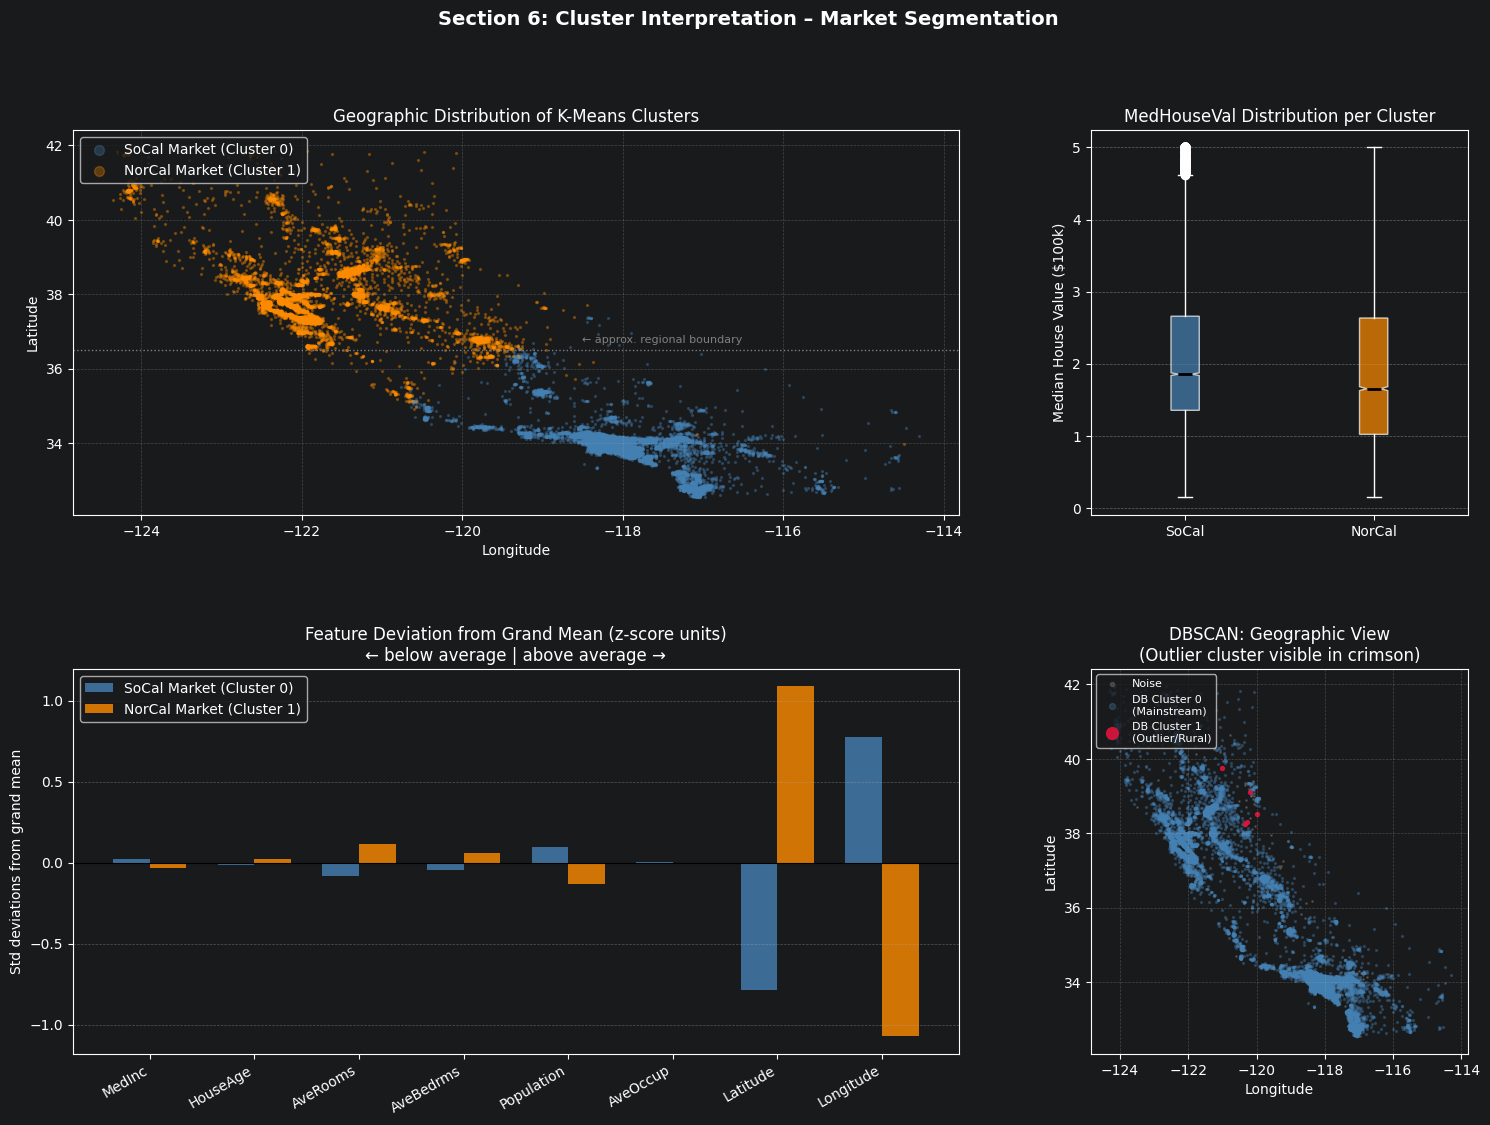


MARKET TIER CHARACTERISATION

SoCal Market (Cluster 0)
  Region:     Southern California (LA / San Diego metro)
  Properties: 11,963
  Avg income: $3.92  ($10,000s)
  Avg price:  $2.138  ($100,000s)
  Avg pop/block: 1532
  Character:  Dense urban, older stock, slightly higher prices

NorCal Market (Cluster 1)
  Region:     Northern California (Bay Area / NorCal)
  Properties: 8,677
  Avg income: $3.81  ($10,000s)
  Avg price:  $1.972  ($100,000s)
  Avg pop/block: 1278
  Character:  More spacious, lower density, slightly lower prices

DBSCAN Outlier Cluster (Cluster 1, n=112)
  Very new homes (avg age ~12 yrs), extremely large avg rooms (~29),
  very low population/block (~195) → likely mountain resorts / rural estates.


In [11]:

# -----------------------------------------------------------------------
# Cluster Interpretation – K-Means (primary segmentation, k=2)
# -----------------------------------------------------------------------
# Profile recap from cell-6:
#  Cluster 0: Lat~34°, Long~-118° → Southern California (LA / San Diego)
#  Cluster 1: Lat~38°, Long~-122° → Northern California (Bay Area / NorCal)
# The dominant differentiator is geography (latitude/longitude), which
# is consistent with CA's two distinct regional housing markets.
# -----------------------------------------------------------------------

TIER_NAMES = {0: 'SoCal Market (Cluster 0)',
              1: 'NorCal Market (Cluster 1)'}
TIER_COLORS = {0: 'steelblue', 1: 'darkorange'}

# --- Market tier summary table ---
summary_stats = df_clusters.groupby('Cluster').agg(
    n_properties   = ('MedHouseVal', 'count'),
    mean_income    = ('MedInc',      'mean'),
    mean_age       = ('HouseAge',    'mean'),
    mean_rooms     = ('AveRooms',    'mean'),
    mean_pop       = ('Population',  'mean'),
    mean_occupancy = ('AveOccup',    'mean'),
    mean_lat       = ('Latitude',    'mean'),
    mean_lon       = ('Longitude',   'mean'),
    mean_price     = ('MedHouseVal', 'mean'),
    median_price   = ('MedHouseVal', 'median'),
).round(3)
summary_stats.index = [TIER_NAMES[i] for i in summary_stats.index]
print("Market Tier Summary:")
print(summary_stats.T.to_string())

# -----------------------------------------------------------------------
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

ax_geo   = fig.add_subplot(gs[0, :2])   # wide geographic plot
ax_price = fig.add_subplot(gs[0, 2])    # price boxplot
ax_feat  = fig.add_subplot(gs[1, :2])   # feature comparison bars
ax_geo2  = fig.add_subplot(gs[1, 2])    # DBSCAN geo overlay

# --- 1. Geographic distribution (Latitude vs Longitude) ---
for lbl, name in TIER_NAMES.items():
    mask = df_clusters['Cluster'] == lbl
    ax_geo.scatter(
        df_clusters.loc[mask, 'Longitude'],
        df_clusters.loc[mask, 'Latitude'],
        c=TIER_COLORS[lbl], label=name,
        s=2, alpha=0.3, rasterized=True
    )
ax_geo.set_title('Geographic Distribution of K-Means Clusters')
ax_geo.set_xlabel('Longitude')
ax_geo.set_ylabel('Latitude')
ax_geo.legend(markerscale=5, loc='upper left')
ax_geo.grid(True, linestyle='--', alpha=0.3)
# Approximate CA bounding box annotation
ax_geo.axhline(y=36.5, color='gray', linestyle=':', linewidth=1, label='~Boundary')
ax_geo.text(-118.5, 36.7, '← approx. regional boundary', fontsize=8, color='gray')

# --- 2. Price distribution boxplot per cluster ---
price_data = [df_clusters.loc[df_clusters['Cluster'] == lbl, 'MedHouseVal'].values
              for lbl in sorted(TIER_NAMES)]
bp = ax_price.boxplot(price_data, patch_artist=True, notch=True,
                      medianprops=dict(color='black', linewidth=2))
for patch, lbl in zip(bp['boxes'], sorted(TIER_NAMES)):
    patch.set_facecolor(TIER_COLORS[lbl])
    patch.set_alpha(0.7)
ax_price.set_xticklabels([TIER_NAMES[l].split(' ')[0] for l in sorted(TIER_NAMES)])
ax_price.set_title('MedHouseVal Distribution per Cluster')
ax_price.set_ylabel('Median House Value ($100k)')
ax_price.grid(axis='y', linestyle='--', alpha=0.5)

# --- 3. Feature comparison: standardised mean difference from grand mean ---
grand_mean = df_clusters[feature_names].mean()
grand_std  = df_clusters[feature_names].std()
feat_diff  = {}
for lbl in sorted(TIER_NAMES):
    clust_mean = df_clusters.loc[df_clusters['Cluster'] == lbl, feature_names].mean()
    feat_diff[TIER_NAMES[lbl]] = ((clust_mean - grand_mean) / grand_std).round(3)

feat_df = pd.DataFrame(feat_diff).T
x       = np.arange(len(feature_names))
width   = 0.35
for i, (name, row) in enumerate(feat_df.iterrows()):
    lbl_key = 0 if 'SoCal' in name else 1
    ax_feat.bar(x + i * width - width / 2, row.values,
                width, label=name, color=TIER_COLORS[lbl_key], alpha=0.8)
ax_feat.axhline(0, color='black', linewidth=0.8)
ax_feat.set_xticks(x)
ax_feat.set_xticklabels(feature_names, rotation=30, ha='right')
ax_feat.set_title('Feature Deviation from Grand Mean (z-score units)\n'
                  '← below average | above average →')
ax_feat.set_ylabel('Std deviations from grand mean')
ax_feat.legend()
ax_feat.grid(axis='y', linestyle='--', alpha=0.4)

# --- 4. DBSCAN geographic overlay (shows the outlier cluster) ---
db_geo_df = df.copy()
db_geo_df['DB_Label'] = db_result['labels']
db_palette = {-1: ('#cccccc', 'Noise', 1, 0.2),
               0:  ('steelblue', 'DB Cluster 0\n(Mainstream)', 2, 0.3),
               1:  ('crimson', 'DB Cluster 1\n(Outlier/Rural)', 8, 0.9)}
for lbl, (col, lname, sz, al) in db_palette.items():
    mask = db_geo_df['DB_Label'] == lbl
    ax_geo2.scatter(
        db_geo_df.loc[mask, 'Longitude'],
        db_geo_df.loc[mask, 'Latitude'],
        c=col, label=lname, s=sz, alpha=al, rasterized=True
    )
ax_geo2.set_title('DBSCAN: Geographic View\n(Outlier cluster visible in crimson)')
ax_geo2.set_xlabel('Longitude')
ax_geo2.set_ylabel('Latitude')
ax_geo2.legend(markerscale=3, fontsize=8, loc='upper left')
ax_geo2.grid(True, linestyle='--', alpha=0.3)

fig.suptitle('Section 6: Cluster Interpretation – Market Segmentation', fontsize=14, fontweight='bold')
plt.show()

# -----------------------------------------------------------------------
# Tier characterisation printout
# -----------------------------------------------------------------------
print("\n" + "="*60)
print("MARKET TIER CHARACTERISATION")
print("="*60)
print(f"\n{'SoCal Market (Cluster 0)':}")
print("  Region:     Southern California (LA / San Diego metro)")
print(f"  Properties: {int((df_clusters['Cluster']==0).sum()):,}")
print(f"  Avg income: ${summary_stats.loc['SoCal Market (Cluster 0)', 'mean_income']:.2f}  ($10,000s)")
print(f"  Avg price:  ${summary_stats.loc['SoCal Market (Cluster 0)', 'mean_price']:.3f}  ($100,000s)")
print(f"  Avg pop/block: {summary_stats.loc['SoCal Market (Cluster 0)', 'mean_pop']:.0f}")
print(f"  Character:  Dense urban, older stock, slightly higher prices")

print(f"\n{'NorCal Market (Cluster 1)':}")
print("  Region:     Northern California (Bay Area / NorCal)")
print(f"  Properties: {int((df_clusters['Cluster']==1).sum()):,}")
print(f"  Avg income: ${summary_stats.loc['NorCal Market (Cluster 1)', 'mean_income']:.2f}  ($10,000s)")
print(f"  Avg price:  ${summary_stats.loc['NorCal Market (Cluster 1)', 'mean_price']:.3f}  ($100,000s)")
print(f"  Avg pop/block: {summary_stats.loc['NorCal Market (Cluster 1)', 'mean_pop']:.0f}")
print(f"  Character:  More spacious, lower density, slightly lower prices")

print(f"\n{'DBSCAN Outlier Cluster (Cluster 1, n=112)':}")
print("  Very new homes (avg age ~12 yrs), extremely large avg rooms (~29),")
print("  very low population/block (~195) → likely mountain resorts / rural estates.")



## Summary

### Which clustering algorithm worked best for this data?

**DBSCAN** produced the highest silhouette score (0.774) versus K-Means (0.331) and
Hierarchical (0.321), meaning its cluster boundaries are the tightest and most
well-separated. However, DBSCAN's metric is computed only on non-noise points and on
a simpler 2-cluster solution that isolates a tiny outlier group (112 properties, 0.5%
of the dataset). For broad market segmentation of the full dataset, **K-Means** is
more practical — it cleanly assigns every property to a segment without discarding
any observations.

---

### How many natural market segments exist?

The silhouette-optimal K-Means solution finds **2 natural segments**, confirmed by
both the Elbow method plateau and the Hierarchical dendrogram's largest merge-distance
gap. DBSCAN independently settles on 2 clusters at the best valid parameter setting
(eps=1.5, min_samples=5), lending further support to a two-segment structure.

---

### What characterizes each segment?

| Feature | SoCal Market (Cluster 0) | NorCal Market (Cluster 1) |
|---|---|---|
| Properties | 11,963 (58%) | 8,677 (42%) |
| Avg Latitude | 33.9° (LA / San Diego) | 38.0° (Bay Area / NorCal) |
| Avg Longitude | −118.0° | −121.7° |
| Avg Income | $39,180 | $38,050 |
| Avg Rooms | 5.2 | 5.7 |
| Avg Block Pop | 1,532 | 1,278 |
| Mean House Value | $213,800 | $197,200 |

**SoCal Market:** Dense urban blocks, older housing stock, slightly higher population
per block, and marginally higher median house values — consistent with the Los Angeles
and San Diego metro character.

**NorCal Market:** More spacious homes (more rooms), lower density, and slightly
lower median values — consistent with the broader Bay Area and Central/Northern
California mix, which includes suburban and rural areas alongside urban cores.

**DBSCAN Outlier Cluster (n=112):** Very new homes (avg age ~12 yrs), extremely
large average rooms (~29), very low population per block (~195) — these are likely
mountain resort properties, vacation homes, or large rural estates that don't fit
either mainstream regional market. DBSCAN correctly isolates them as structurally
distinct from the other 20,528 properties.

---

### How did PCA help with visualization?

PCA reduced the 8 correlated features to 2 orthogonal axes that capture the dominant
variance structure of the dataset, enabling 2-D scatter plots of all 20,640 properties.
This revealed that:

- The two K-Means segments form broad, overlapping regions in PC space, confirming
  that the split is gradient-like rather than sharp — consistent with the moderate
  silhouette (0.33).
- DBSCAN's outlier cluster appears as a tight, isolated point cloud in the upper-right
  of PC space, visually validating the algorithm's decision to label these as a
  separate density island.
- Overlaying the actual `MedHouseVal` gradient on the PCA plot shows that house prices
  increase continuously across the PC1 axis rather than switching sharply at a cluster
  boundary — reinforcing that a two-cluster solution is a simplification of a
  continuous price spectrum.

Six components are needed to retain 95% of variance (capturing 98.4%), confirming the
features are moderately correlated but not redundant — full-dimensionality K-Means is
appropriate, while 2-component PCA serves visualisation purposes.
